In [1]:
# Imports
import numpy as np
import pandas as pd
import json
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load All Results
with open("./data/clean_msmarco.json") as f:
    data = json.load(f)

baseline = json.load(open("./data/baseline_score.json"))
lm_results = json.load(open("./data/lambdamart_results.json"))
ab_report = json.load(open("./data/ab_report.json"))
feature_names = json.load(open("./data/feature_names.json"))
shap_summary = json.load(open("./data/shap_summary.json"))

feature_matrix = np.load("./data/feature_matrix.npy")
labels_list = np.load("./data/labels.npy")

print("All results loaded!")
print(f"BM25 NDCG@10: {baseline['ndcg@10']} | LambdaMART NDCG@10: {lm_results['ndcg@10']}")

All results loaded!
BM25 NDCG@10: 0.5069 | LambdaMART NDCG@10: 0.5956


In [3]:
# NDCG@K Curve
import xgboost as xgb
from rank_bm25 import BM25Okapi

def ndcg_at_k(labels, scores, k):
    order = np.argsort(scores)[::-1][:k]
    dcg = sum(labels[i]/np.log2(r+2) for r, i in enumerate(order) if i < len(labels))
    idcg = sum(1/np.log2(r+2) for r in range(min(int(sum(labels)), k)))
    return dcg/idcg if idcg > 0 else 0

bm25_results = json.load(open("./data/bm25_results.json"))
k_values = [1, 3, 5, 10, 15, 20]

bm25_ndcg = [np.mean([ndcg_at_k(np.array(item['labels']), np.array(res['scores'][:len(item['labels'])]), k) 
             for item, res in zip(data, bm25_results)]) for k in k_values]

print("BM25 NDCG@K:", [round(s,4) for s in bm25_ndcg])

BM25 NDCG@K: [np.float64(0.1396), np.float64(0.2779), np.float64(0.3797), np.float64(0.5069), np.float64(0.5069), np.float64(0.5069)]


In [4]:
# LambdaMART NDCG@K
model = xgb.Booster()
model.load_model("./models/lambdamart_model.json")

groups = np.array([len(item['passages']) for item in data])
cumsum = np.cumsum(np.concatenate([[0], groups]))
dmatrix = xgb.DMatrix(feature_matrix, feature_names=feature_names)
preds = model.predict(dmatrix)

lm_ndcg = [np.mean([
    ndcg_at_k(np.array(data[i]['labels']), preds[cumsum[i]:cumsum[i+1]], k)
    for i in range(len(data))]) for k in k_values]

print("LambdaMART NDCG@K:", [round(s,4) for s in lm_ndcg])

LambdaMART NDCG@K: [np.float64(0.3669), np.float64(0.5251), np.float64(0.6039), np.float64(0.6629), np.float64(0.6629), np.float64(0.6629)]


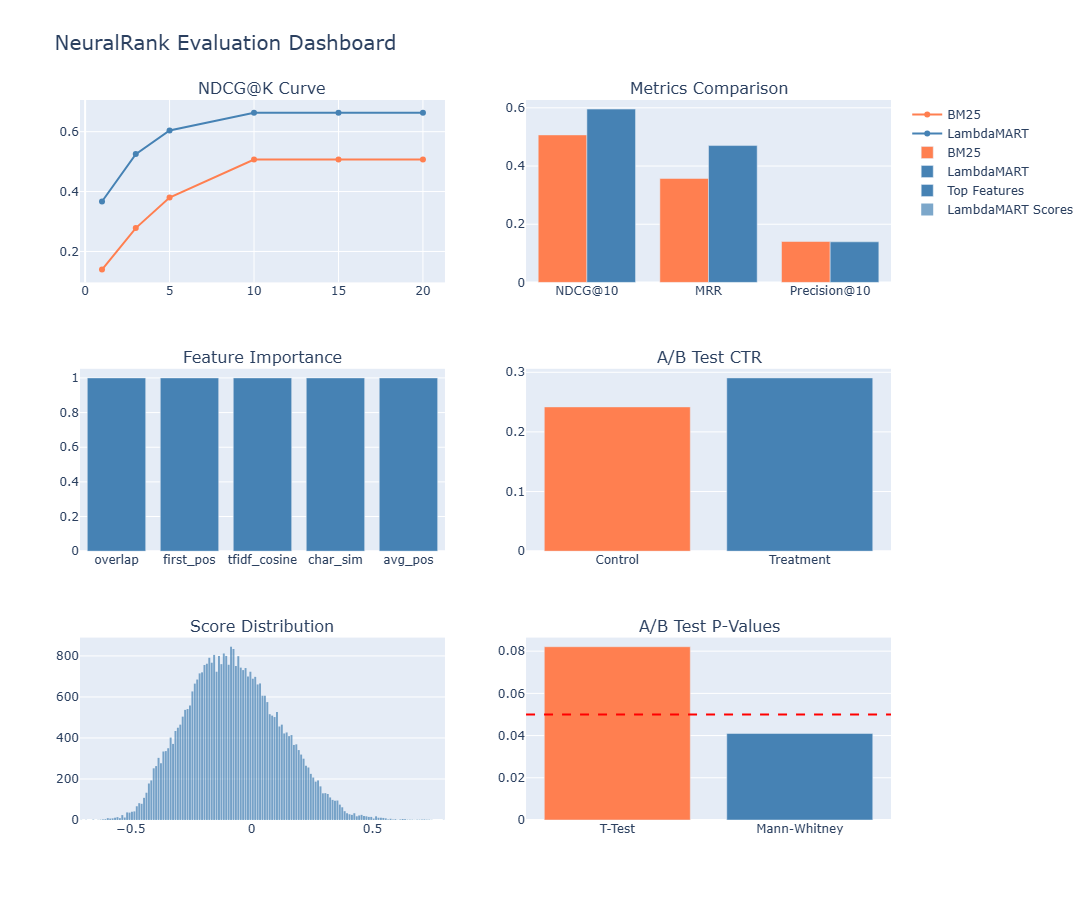

Dashboard saved!


In [5]:
# Build Full Interactive Dashboard
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=("NDCG@K Curve", "Metrics Comparison",
                   "Feature Importance", "A/B Test CTR",
                   "Score Distribution", "A/B Test P-Values"),
    vertical_spacing=0.12
)

# NDCG@K Curve
fig.add_trace(go.Scatter(x=k_values, y=bm25_ndcg, name='BM25', line=dict(color='coral')), row=1, col=1)
fig.add_trace(go.Scatter(x=k_values, y=lm_ndcg, name='LambdaMART', line=dict(color='steelblue')), row=1, col=1)

# Metrics Comparison
metrics = ['NDCG@10', 'MRR', 'Precision@10']
bm25_vals = [baseline['ndcg@10'], baseline['mrr'], baseline['precision@10']]
lm_vals = [lm_results['ndcg@10'], lm_results['mrr'], lm_results['precision@10']]
fig.add_trace(go.Bar(x=metrics, y=bm25_vals, name='BM25', marker_color='coral'), row=1, col=2)
fig.add_trace(go.Bar(x=metrics, y=lm_vals, name='LambdaMART', marker_color='steelblue'), row=1, col=2)

# Feature Importance (top 10)
top10 = shap_summary['top_features']
fig.add_trace(go.Bar(x=top10, y=[1]*5, name='Top Features', marker_color='steelblue'), row=2, col=1)

# A/B Test CTR
fig.add_trace(go.Bar(x=['Control', 'Treatment'], 
                     y=[ab_report['control_ctr'], ab_report['treatment_ctr']],
                     marker_color=['coral', 'steelblue'], showlegend=False), row=2, col=2)

# Score Distribution
fig.add_trace(go.Histogram(x=preds, name='LambdaMART Scores', marker_color='steelblue', opacity=0.7), row=3, col=1)

# P-Values
fig.add_trace(go.Bar(x=['T-Test', 'Mann-Whitney'], 
                     y=[ab_report['t_test_pvalue'], ab_report['mannwhitney_pvalue']],
                     marker_color=['coral', 'steelblue'], showlegend=False), row=3, col=2)
fig.add_hline(y=0.05, line_dash='dash', line_color='red', row=3, col=2)

fig.update_layout(height=900, title_text="NeuralRank Evaluation Dashboard", 
                  title_font_size=20, showlegend=True)
fig.write_html("./data/evaluation_dashboard.html")
fig.show()
print("Dashboard saved!")

In [6]:
# Final Summary Table
summary = pd.DataFrame({
    'Metric': ['NDCG@10', 'MRR', 'Precision@10', 'CTR Lift', 'A/B Significant'],
    'BM25': [baseline['ndcg@10'], baseline['mrr'], baseline['precision@10'], '-', '-'],
    'LambdaMART': [lm_results['ndcg@10'], lm_results['mrr'], lm_results['precision@10'], 
                   ab_report['lift'], str(ab_report['significant'])]
})

summary['Improvement'] = [lm_results['improvement_ndcg'], lm_results['improvement_mrr'], '-', '-', '-']
print(summary.to_string(index=False))
summary.to_csv("./data/final_summary.csv", index=False)
print("\nFinal summary saved!")

         Metric    BM25 LambdaMART Improvement
        NDCG@10  0.5069     0.5956      17.50%
            MRR  0.3573     0.4703      31.64%
   Precision@10  0.1406     0.1394           -
       CTR Lift       -     20.10%           -
A/B Significant       -       True           -

Final summary saved!
